# Using ICA to reduce artefacts

This section will demonstrate how to use an independent component analysis (ICA) approach to suppress ocular and cardiac artefacts. First, the data will be decomposed using ICA, after which the components reflecting the artefacts will be identified manually. As a last step, the artefact components will be 'projected out'.

## Preparation
### Import the necessary modules
Below are the required Python modules to be imported

In [1]:
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne_bids import BIDSPath, read_raw_bids
from mne.preprocessing import ICA
from IPython.display import Image, display

### File overview

This section reads the annotated recording produced in the previous section:
```
<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann_raw.fif
```
and writes the ICA-cleaned data:
```
<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ica_raw.fif
```

The filtered data is saved in the derivative folder of the BIDS Directory. 


Specify the BIDS parameters along with the path to the BIDS folder:

In [2]:
subject = '01'
session = '01'
task = 'SpAtt'
run = '01'
meg_suffix = 'meg'
hfc_suffix = 'hfc_raw'
ann_suffix = 'ann_raw'
ica_suffix = 'ica_raw'

# data_path = 'E:/Data/Cerca'
data_path = '/Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif'

bids_root = op.join(data_path, "Cerca_Spatt_BIDS")
deriv_root = op.join(bids_root, "derivatives/preprocessing")

bids_path = BIDSPath(subject=subject, session=session, datatype='meg',
            task=task, run=run, suffix=ann_suffix,
            root=deriv_root, extension='.fif', check=False)

deriv_fname = bids_path.basename.replace(ann_suffix, ica_suffix)  # fif output filename
deriv_fname_fif = op.join(bids_path.directory, deriv_fname)

print(bids_path)
print(deriv_fname_fif)

/Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann_raw.fif
/Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ica_raw.fif


## Resampling and filtering of the raw data

To make the ICA algorithm run more efficiently, the data are first filtered and downsampled. We start from the version of the dataset that has already been cleaned with homogeneous field correction and carries the artefact annotations. A band-pass filter of 3–30 Hz is applied and the data are then resampled to 250 Hz. The high-pass filter is particularly important, because removing slow drifts makes the ICA decomposition considerably more effective.

Note that this filtering and downsampling is only used to *estimate* the ICA components. The resulting unmixing is later applied to the full-resolution (750 Hz) data, so the downsampling here is temporary and does not affect the data that are ultimately saved.

In [3]:
# Read the annotated raw data from the BIDS derivatives path
raw = read_raw_bids(bids_path=bids_path, extra_params={'preload': True}, verbose=True)

# Prepare a temporary copy for ICA estimation: magnetometers only, band-pass filtered and downsampled
raw_resmpl = raw.copy().pick('mag')
raw_resmpl.filter(l_freq=3, h_freq=30)
raw_resmpl.resample(250)

Opening raw data file /Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann_raw.fif...
    Read a total of 8 projection items:
        HFC: l=1 m=0 (1 x 176) active
        HFC: l=2 m=0 (1 x 176) active
        HFC: l=1 m=-1 (1 x 176) active
        HFC: l=1 m=1 (1 x 176) active
        HFC: l=2 m=-1 (1 x 176) active
        HFC: l=2 m=1 (1 x 176) active
        HFC: l=2 m=-2 (1 x 176) active
        HFC: l=2 m=2 (1 x 176) active
    Range : 0 ... 1539807 =      0.000 ...  2053.076 secs
Ready.
Reading 0 ... 1539807  =      0.000 ...  2053.076 secs...


/var/folders/n0/w7vb4jpn0nx3hs95f4p7r9br0000gr/T/ipykernel_85145/1229556583.py:2: RuntimeWarning: Did not find any events.tsv associated with sub-01_ses-01_task-SpAtt_run-01.

The search strings were:
/Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/sub-01*events.tsv
/Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/meg/sub-01*events.tsv
/Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/sub-01_ses-01*events.tsv
/Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01*events.tsv
  raw = read_raw_bids(bids_path=bids_path, extra_params={'preload': True}, verbose=True)
/var/folders/n0/w7vb4jpn0nx3hs95f4p7r9br0000gr/T/ipykernel_85145/1229556583.py:2: RuntimeWarning: Did not find any channels.tsv associated with sub-01_ses-01_task-SpAtt_run-01.

The search strings were:
/Users/o.jensen@bha

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 3.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1239 samples (1.652 s)



<Raw | sub-01_ses-01_task-SpAtt_run-01_ann_raw.fif, 176 x 513269 (2053.1 s), ~694.8 MiB, data loaded>

## Applying the ICA algorithm

The ICA algorithm is now applied. The **fastICA** algorithm is chosen here as it is well-established and widely used, though other ICA methods are available in MNE-Python. To speed up the computation, a Principal Component Analysis (PCA) is used to reduce the data to 30 dimensions before fitting the ICA.

In [4]:
ica = ICA(method='fastica',
          random_state=96,
          n_components=30,
          verbose=False)

ica.fit(raw_resmpl, picks='meg', verbose=False)

Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,48 iterations on raw data (502741 samples)
ICA components,30
Available PCA components,176
Channel types,mag
ICA components marked for exclusion,—



## Identifying the ICA components reflecting the artefacts

To plot the examples for the time-traces of the ICA components use:


    Applying projection operator with 8 vectors (pre-whitener application)
Creating RawArray with float64 data, n_channels=30, n_times=513269
    Range : 0 ... 513268 =      0.000 ...  2053.072 secs
Ready.
Using matplotlib as 2D backend.


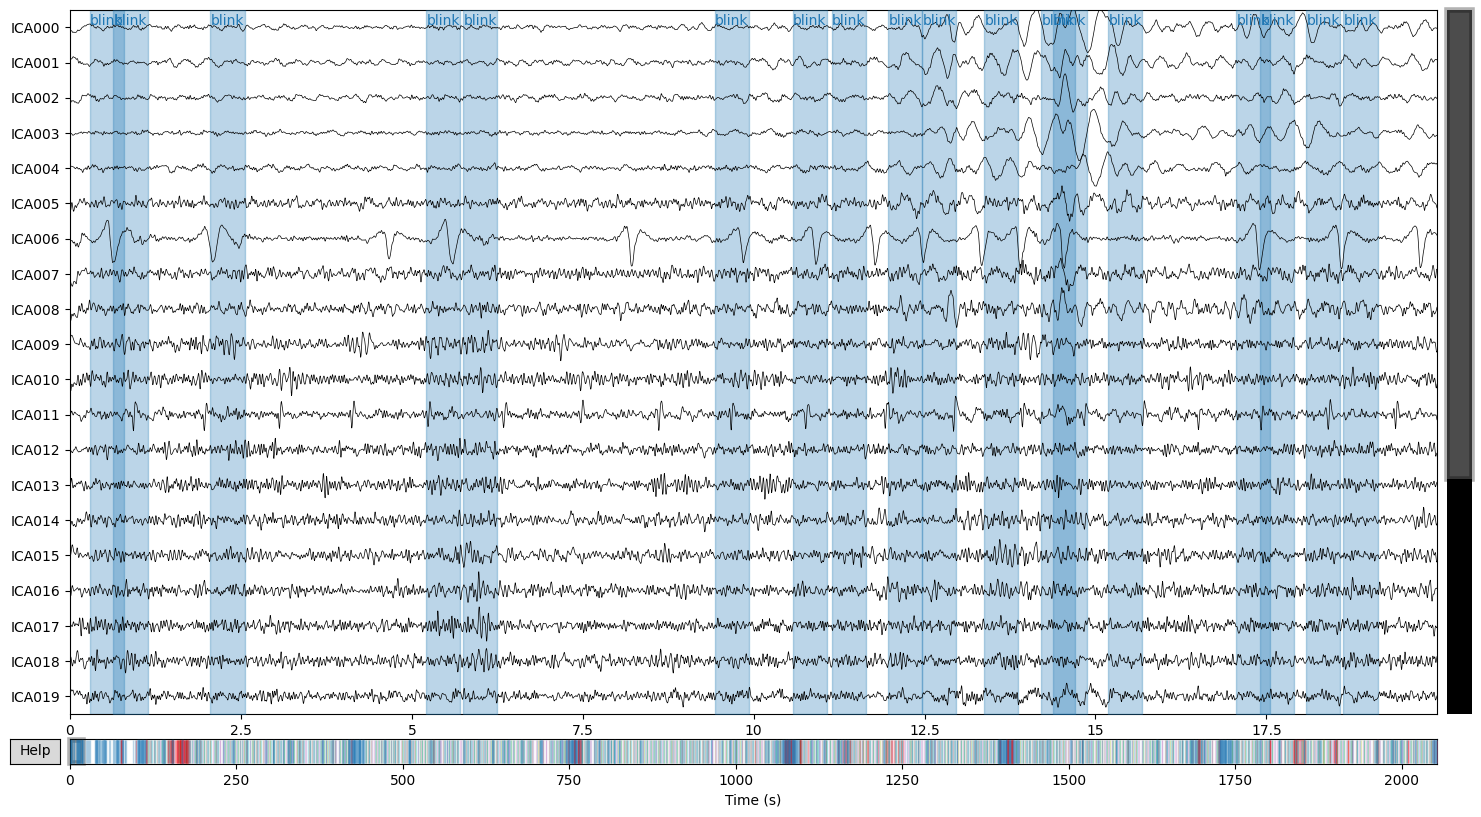

In [5]:
%matplotlib inline
ica.plot_sources(raw_resmpl, title='ICA');

This script will open an interactive session. Use the left/right arrow-keys to scroll through the data and the up/down arrow-keys to scroll through the components. 

Please see an example below. 

In [6]:
image_url = 'https://github.com/FLUX-pipeline/Cerca/blob/main/ICAexample.png?raw=true'
display(Image(url=image_url))

### Topographic plots of the ICA components 

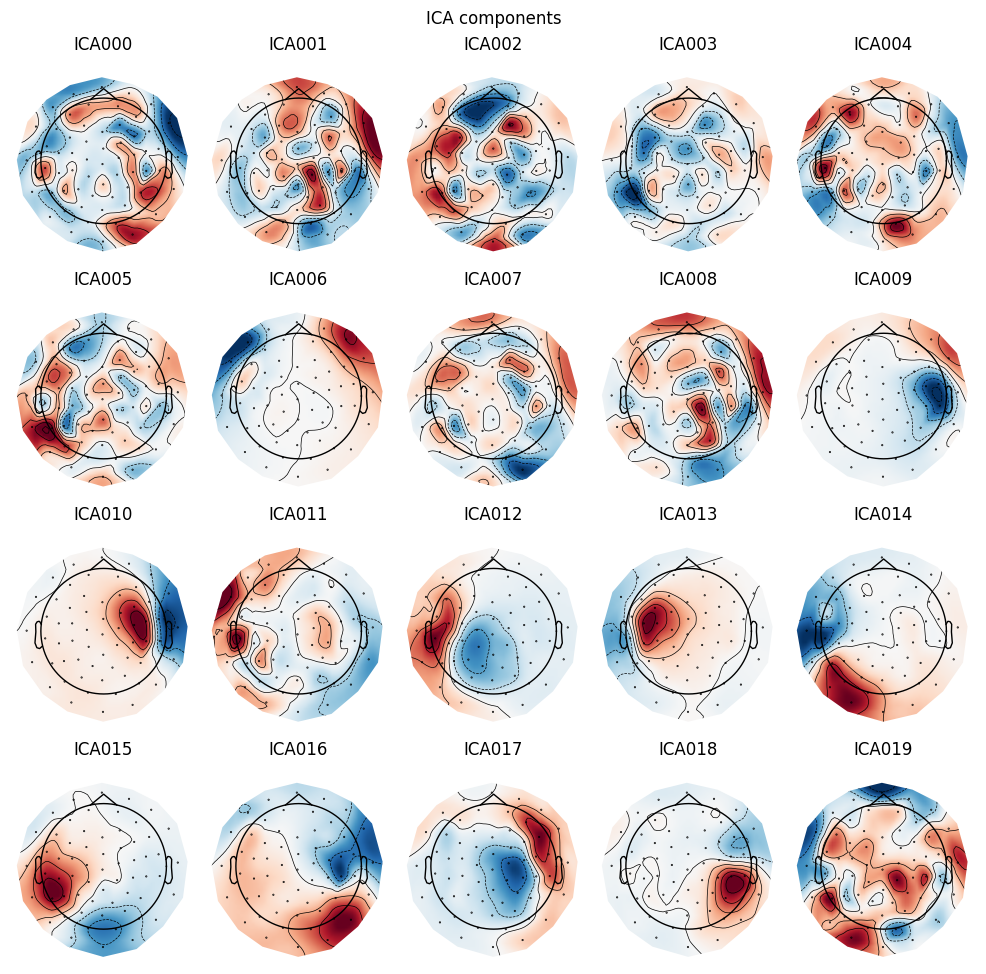

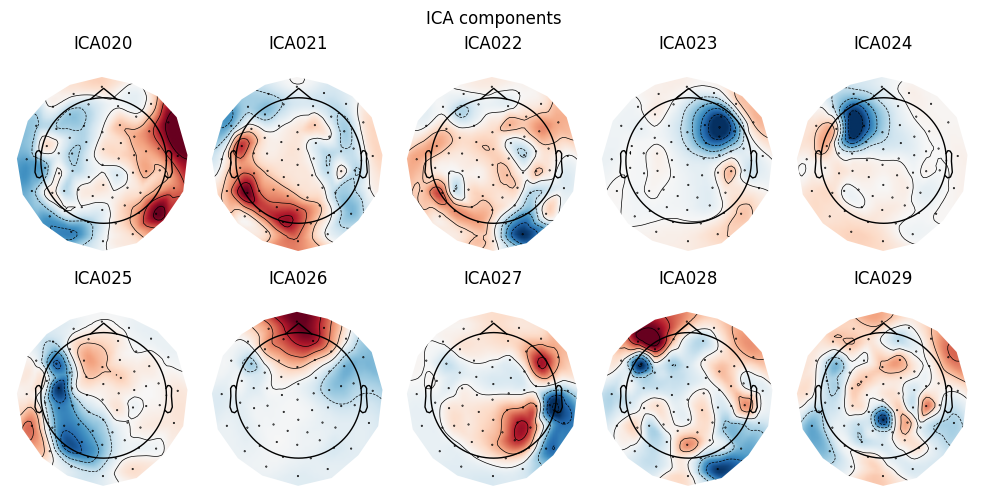

[<MNEFigure size 975x967 with 20 Axes>, <MNEFigure size 975x496 with 10 Axes>]

In [7]:
ica.plot_components()

In this example, component 6 reflects eye blinks, while component 11 reflects cardiac artefacts — the QRS complex is clearly visible at a rate of about 1 Hz.

Note that the indices of the components are **not** deterministic: they can change depending on the platform and software version. For instance, on a Mac the cardiac component appeared as component 18, whereas on a Windows PC it appeared as component 11. Always identify the artefact components from their time courses and topographies rather than relying on fixed indices.

**Question 1** Muscle artefacts do not seem to be captured by a single ICA component. Why might that be?

## Attenuating ocular and cardiac artefacts by applying the projections

The ICA components associated with ocular and cardiac artefacts have now been identified and will be 'projected out'. This is done by listing them in `ica.exclude` and applying the ICA solution (`ica.apply`) to the original full-resolution raw data, which is loaded again. After the artefact components have been removed, the cleaned data are saved.

In [ ]:
# Components to exclude (blink and cardiac); adjust these indices to match your own decomposition
ica.exclude = [6, 11]

# Reload the full-resolution data and remove the excluded components
raw_ica = read_raw_bids(bids_path=bids_path, extra_params={'preload': True}, verbose=True)
ica.apply(raw_ica)

raw_ica.save(deriv_fname_fif, overwrite=True)


## Plotting the data to check the artefact reduction

We will here examine some of the traces to demonstrate the artefact reduction.

Define a few frontal OPM sensors to examine

For the sake of understanding sensor-positions will be plotted in a topographic representation

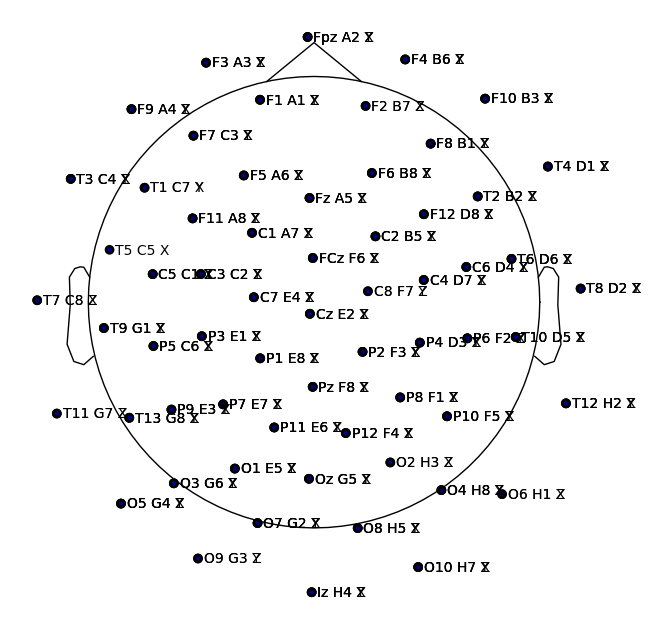

In [12]:
raw_ica.plot_sensors(kind='topomap', show_names=True);

The frontal sensor 'F9 A4 Z' happens to be sensitive to eye blinks, so it is a good channel for illustrating the artefact reduction.

In [ ]:
picks = mne.pick_types(raw.info, include=['F9 A4 Z'])

amp_scale = 1e12  # convert Tesla to picotesla (pT)

data_ds, time_ds = raw[picks]           # before ICA (with artefacts)
dataICA_ds, timeICA_ds = raw_ica[picks]  # after ICA

plt.plot(time_ds, amp_scale * data_ds.T, label='before ICA')
plt.plot(timeICA_ds, amp_scale * dataICA_ds.T, label='after ICA')
plt.legend()
plt.xlim(1130, 1160)
plt.ylim(-20, 20)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (pT)')

In the plot above, it is clear that the ICA effectively reduces the eye-blink artefacts.

## Preregistration and Publication

A preregistration should specify the ICA pipeline in enough detail to be reproduced exactly. ICA-based artefact rejection is partly subjective (components are usually selected by eye), so it is especially important to state the criteria in advance. We recommend committing to the following:

**ICA estimation**
- The preprocessing applied before fitting: channel selection (magnetometers), band-pass filter (here 3–30 Hz), and downsampling (here 250 Hz). Note that the high-pass filter strongly affects ICA quality.
- The algorithm (`fastica`), the number of components / PCA dimensionality (here 30), and the random seed (`random_state`) for reproducibility.

**Component selection and removal**
- How artefact components are identified (visual inspection of time courses and topographies, and/or automated methods such as `find_bads_eog` / `find_bads_ecg`).
- Which artefact classes are targeted (here ocular and cardiac) and the expected number of components removed per participant.
- That component indices are not deterministic across platforms, so selection must be based on component properties, not fixed indices.
- That the ICA solution, estimated on the filtered/downsampled data, is applied to the full-resolution data.

**General**
- Software and versions (MNE-Python, MNE-BIDS).
- Where the cleaned data are stored (`*_ica_raw.fif` in BIDS `derivatives`).

**Example preregistration / methods text**

> "The data were band-pass filtered to 3–30 Hz and downsampled to 250 Hz prior to Independent Component Analysis (ICA). The fastICA algorithm (Hyvärinen & Oja, 2000) as implemented in MNE-Python was then applied to the magnetometer data, reduced to 30 dimensions by PCA. Components reflecting cardiac artefacts and eye blinks were identified from their time courses and topographies and removed (2–5 components per participant). The ICA solution was applied to the full-resolution data, which were then saved."

## References

[1] Hyvärinen, A., & Oja, E. (2000). Independent component analysis: algorithms and applications. *Neural Networks*, **13**(4–5), 411–430. [https://doi.org/10.1016/S0893-6080(00)00026-5](https://doi.org/10.1016/S0893-6080(00)00026-5)